# Analysing NN simulations

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we analyse the simulation done on Dardel. We load the .h5 file and run some analysis. Some of these have to be integrated directly in the simulation scripts.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.NN_simulation_analysis_helper import *
from utils.Plots_helper import *

In [4]:
file_name='testing_80p_v0/ictal_interictal_synchro_IMP_cr_Z0_-50_tau_r_08.h5'

In [5]:
data=load_ictal_interictal_synchro_h5(file_name)

In [6]:
meta = data[0]
ictal = data[1]
interictal = data[2]
synch = data[3]

In [7]:
pops = ['FS','RS','IMP']

In [8]:
sim_duration = data[0]['sim_duration']*b2.second
bin_size = 0.1 * b2.second
bin_edges = np.arange(0, sim_duration + bin_size, bin_size)

time_bins = time_bins = bin_edges[:-1] + (bin_size/b2.second / 2) 

In [9]:
'''
fig, time_bins, mean_rate_FS, mean_rate_RS, mean_rate_IMP = plotting_pop_freq_and_std_h5(
                                                  sim_duration = data[0]['sim_duration']*b2.second, 
                                                  pop1 = data[1]['FS'], 
                                                  pop2 = data[1]['RS'], 
                                                  pop3 = data[1]['IMP'],
                                                  N_pop1 = data[0]['num_FS_neurons'],
                                                  N_pop2 = data[0]['num_RS_neurons'],
                                                  N_pop3 = data[0]['num_IMP_neurons'])
'''

"\nfig, time_bins, mean_rate_FS, mean_rate_RS, mean_rate_IMP = plotting_pop_freq_and_std_h5(\n                                                  sim_duration = data[0]['sim_duration']*b2.second, \n                                                  pop1 = data[1]['FS'], \n                                                  pop2 = data[1]['RS'], \n                                                  pop3 = data[1]['IMP'],\n                                                  N_pop1 = data[0]['num_FS_neurons'],\n                                                  N_pop2 = data[0]['num_RS_neurons'],\n                                                  N_pop3 = data[0]['num_IMP_neurons'])\n"

### Extracting ictal and interictal regimes

In [10]:
#ictal['FS'], interictal['FS']

In [11]:
ictal_FS = ictal['FS']
ictal_RS = ictal['RS']
ictal_IMP = ictal['IMP']

interictal_FS = interictal['FS']
interictal_RS = interictal['RS']
interictal_IMP = interictal['IMP']

In [12]:
ictal = {'FS':ictal_FS, 'RS':ictal_RS, 'IMP':ictal_IMP}
interictal = {'FS':interictal_FS, 'RS':interictal_RS, 'IMP':interictal_IMP}

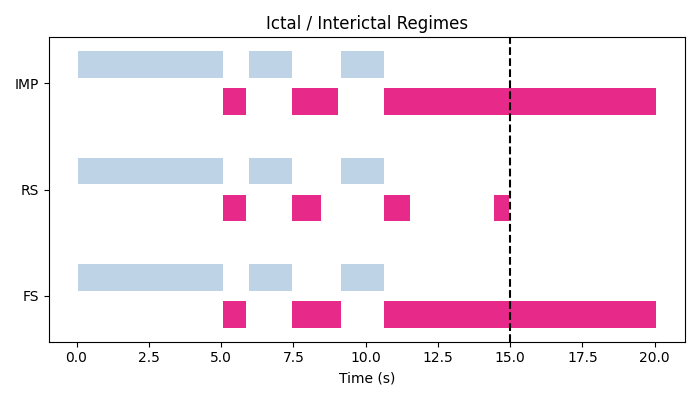

In [13]:
fig = plot_regime_timeline_h5(ictal, interictal, pops, split_time = data[0]['p_end'])

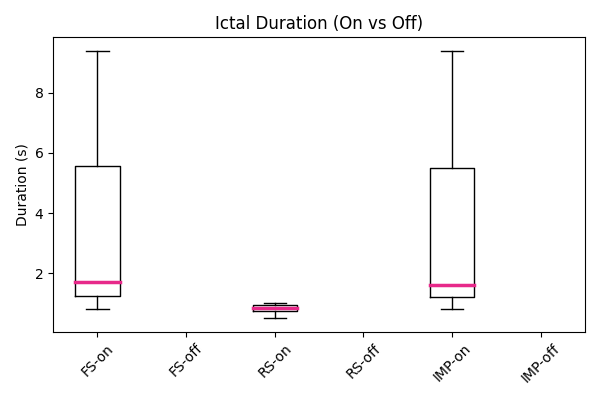

In [14]:
fig = plot_ictal_regime_duration_h5(ictal, pops, split_time = data[0]['p_end'])

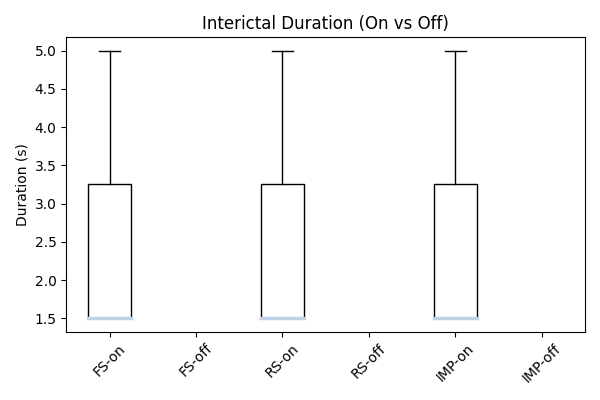

In [15]:
fig = plot_interictal_regime_duration_h5(interictal, pops, split_time = data[0]['p_end'])

## Synchronicity

In [16]:
sync_FS = data[3]['FS']
sync_RS = data[3]['RS']
sync_IMP = data[3]['IMP']

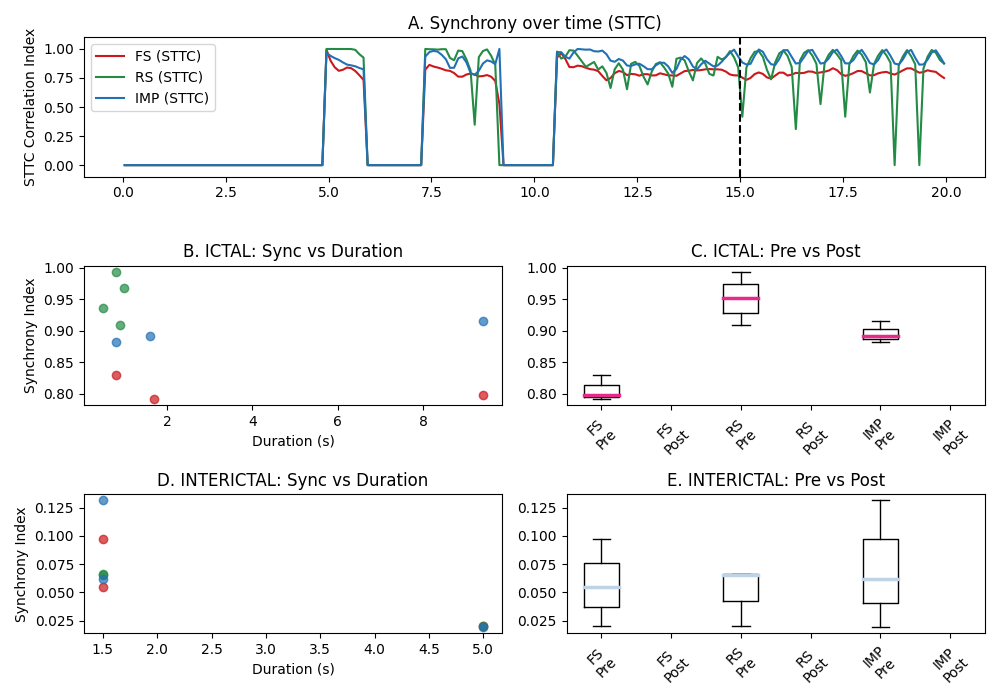

In [17]:
fig = plot_synchrony_panels_h5(pops, ictal, interictal,
                            sync_FS, sync_RS, sync_IMP,
                            time_bins, split_time=data[0]['p_end'])